# Customer Churn Analysis
## SQL, Statistics, Machine Learning & Professional Publishing

Integrated analysis of a telecommunications customer churn dataset: SQL querying,
statistical hypothesis testing, and machine learning classification to understand and
predict customer churn.

**Dataset source:** https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv


## Part 1: SQL Queries

In [1]:
import sqlite3
import pandas as pd
import numpy as np

# Load the dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Load into a SQLite database
conn = sqlite3.connect("churn.db")
df.to_sql("customers", conn, if_exists="replace", index=False)

print("Loaded", len(df), "rows into the 'customers' table.")
df.head()


Loaded 7043 rows into the 'customers' table.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


All queries below are also saved together in `churn_queries.sql`.

### Customer Overview

In [2]:
q1 = pd.read_sql_query("""
    SELECT COUNT(*) AS total_customers
    FROM customers;
""", conn)
q1


,total_customers
0,7043


In [3]:
q2 = pd.read_sql_query("""
    SELECT COUNT(*) AS churned_customers
    FROM customers
    WHERE Churn = 'Yes';
""", conn)
q2


,churned_customers
0,1869


### Demographics

In [4]:
q3 = pd.read_sql_query("""
    SELECT gender, COUNT(*) AS customer_count
    FROM customers
    GROUP BY gender;
""", conn)
q3


,gender,customer_count
0,Female,3488
1,Male,3555


In [5]:
q4 = pd.read_sql_query("""
    SELECT COUNT(*) AS senior_citizen_count
    FROM customers
    WHERE SeniorCitizen = 1;
""", conn)
q4


,senior_citizen_count
0,1142


### Contract & Tenure

In [6]:
q5 = pd.read_sql_query("""
    SELECT Churn, AVG(tenure) AS avg_tenure
    FROM customers
    GROUP BY Churn;
""", conn)
q5


,Churn,avg_tenure
0,No,37.569965
1,Yes,17.979133


In [7]:
q6 = pd.read_sql_query("""
    SELECT Contract, COUNT(*) AS customer_count
    FROM customers
    GROUP BY Contract;
""", conn)
q6


,Contract,customer_count
0,Month-to-month,3875
1,One year,1473
2,Two year,1695


### Internet Service & Charges

In [8]:
q7 = pd.read_sql_query("""
    SELECT InternetService, AVG(MonthlyCharges) AS avg_monthly_charges
    FROM customers
    GROUP BY InternetService;
""", conn)
q7


,InternetService,avg_monthly_charges
0,DSL,58.102169
1,Fiber optic,91.500129
2,No,21.079194


In [9]:
# Note: TotalCharges is stored as TEXT in the raw CSV (it contains blank strings
# for a handful of new customers), so it is cast to a numeric type for the SUM.
q8 = pd.read_sql_query("""
    SELECT PaymentMethod, SUM(CAST(NULLIF(TRIM(TotalCharges), '') AS REAL)) AS total_charges_sum
    FROM customers
    GROUP BY PaymentMethod;
""", conn)
q8


,PaymentMethod,total_charges_sum
0,Bank transfer (automatic),4748279.90
1,Credit card (automatic),4671593.35
2,Electronic check,4944903.25
3,Mailed check,1691392.20


### Churn Drivers

In [10]:
q9 = pd.read_sql_query("""
    SELECT
        Contract,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
        ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY Contract
    ORDER BY churn_rate_pct DESC;
""", conn)
q9


,Contract,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [11]:
q10 = pd.read_sql_query("""
    SELECT
        InternetService,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
        ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY InternetService
    ORDER BY churn_rate_pct DESC;
""", conn)
q10


,InternetService,total_customers,churned_customers,churn_rate_pct
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40


In [12]:
q11 = pd.read_sql_query("""
    SELECT
        OnlineSecurity,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
        ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY OnlineSecurity
    ORDER BY churn_rate_pct DESC;
""", conn)
q11


,OnlineSecurity,total_customers,churned_customers,churn_rate_pct
0,No,3498,1461,41.77
1,Yes,2019,295,14.61
2,No internet service,1526,113,7.40


### Advanced Aggregation

In [13]:
q12 = pd.read_sql_query("""
    SELECT
        Contract,
        InternetService,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
        ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY Contract, InternetService
    HAVING COUNT(*) >= 30
    ORDER BY churn_rate_pct DESC
    LIMIT 5;
""", conn)
q12


,Contract,InternetService,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,Fiber optic,2128,1162,54.61
1,Month-to-month,DSL,1223,394,32.22
2,One year,Fiber optic,539,104,19.29
3,Month-to-month,No,524,99,18.89
4,One year,DSL,570,53,9.30


## Part 2: Statistical Analysis & Hypothesis Testing

In [14]:
# Clean TotalCharges: convert to numeric, fill blanks with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total_charges)

print("Missing TotalCharges filled with median:", median_total_charges)


Missing TotalCharges filled with median: 1397.475


In [15]:
desc_stats = df[['tenure', 'MonthlyCharges', 'TotalCharges']].agg(['mean', 'median', 'std'])
desc_stats


,tenure,MonthlyCharges,TotalCharges
mean,32.371149,64.761692,2281.916928
median,29.000000,70.350000,1397.475000
std,24.559481,30.090047,2265.270398


**Interpretation:** `tenure` and `TotalCharges` both show a noticeably larger gap between their
mean and median compared to `MonthlyCharges`, indicating right-skew — a large group of relatively new,
low-tenure/low-total-spend customers pulls the mean down relative to a smaller group of long-tenured,
high-total-spend customers. `MonthlyCharges` is more evenly spread, with mean and median close together,
suggesting fewer extreme outliers in monthly billing amounts than in cumulative tenure/spend.

In [16]:
from scipy.stats import chi2_contingency

# Chi-square test: association between Contract and Churn
contingency_table = pd.crosstab(df['Contract'], df['Churn'])
chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_table)

print("Contingency table:")
print(contingency_table)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value_chi2:.2e}")


Contingency table:
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Chi-square statistic: 1184.60
Degrees of freedom: 2
p-value: 5.86e-258


**Interpretation:** The p-value is far below the conventional 0.05 threshold, so we reject the null
hypothesis of independence. There is a statistically significant association between `Contract` type
and `Churn` — customers on month-to-month contracts churn at a much higher rate than those on one- or
two-year contracts.

In [17]:
from scipy.stats import ttest_ind

churned_charges = df.loc[df['Churn'] == 'Yes', 'MonthlyCharges']
retained_charges = df.loc[df['Churn'] == 'No', 'MonthlyCharges']

t_stat, p_value_ttest = ttest_ind(churned_charges, retained_charges, equal_var=False)

print(f"Mean MonthlyCharges (churned):    {churned_charges.mean():.2f}")
print(f"Mean MonthlyCharges (non-churned): {retained_charges.mean():.2f}")
print(f"\nt-statistic: {t_stat:.2f}")
print(f"p-value: {p_value_ttest:.2e}")


Mean MonthlyCharges (churned):    74.44
Mean MonthlyCharges (non-churned): 61.27

t-statistic: 18.41
p-value: 8.59e-73


**Interpretation:** The p-value is well below 0.05, so the difference in average `MonthlyCharges`
between churned and non-churned customers is statistically significant. Churned customers pay
meaningfully higher average monthly charges than customers who stay, suggesting price sensitivity is
a factor in churn decisions.

### Business Insight

Because month-to-month contracts and higher monthly charges are both statistically significantly
associated with churn, the company should prioritize converting month-to-month customers — especially
those paying above-average monthly charges — onto discounted one- or two-year contracts, since locking
in a longer commitment (even with a modest price incentive) directly targets the two strongest,
statistically validated drivers of churn.

## Part 3: Machine Learning

### Data Preparation

In [18]:
from sklearn.model_selection import train_test_split

df_ml = df.copy()

# Target: map Churn to 0/1
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID (identifier, not predictive)
df_ml = df_ml.drop(columns=['customerID'])

# Encode categorical variables with one-hot encoding
categorical_cols = df_ml.select_dtypes(include='object').columns.tolist()
df_ml_encoded = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# Define features X and target y
X = df_ml_encoded.drop(columns=['Churn'])
y = df_ml_encoded['Churn']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))


Feature matrix shape: (7043, 30)
Target distribution:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


/tmp/ipykernel_564/2768752519.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_ml.select_dtypes(include='object').columns.tolist()


In [19]:
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5634, 30)
Test shape: (1409, 30)


### Baseline Model — Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy:  {acc_lr:.3f}")
print(f"Precision: {prec_lr:.3f}")
print(f"Recall:    {rec_lr:.3f}")
print(f"F1 score:  {f1_lr:.3f}")


Accuracy:  0.806
Precision: 0.657
Recall:    0.559
F1 score:  0.604


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


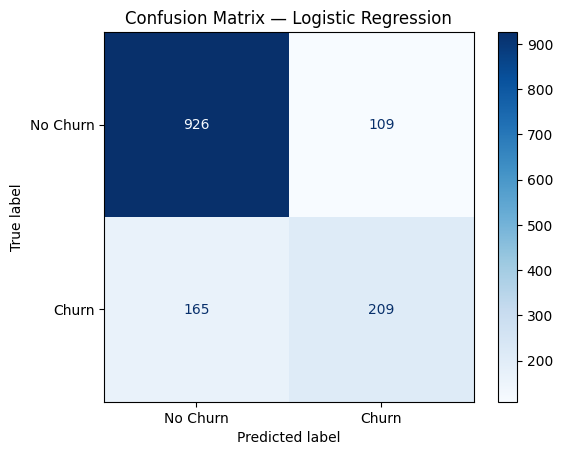

In [21]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


### Tree-Based Models

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree (max depth 4)
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Random Forest (100 trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (depth=4)', 'Random Forest (100 trees)'],
    'Accuracy': [acc_lr, acc_dt, acc_rf]
})
comparison


,Model,Accuracy
0,Logistic Regression,0.805536
1,Decision Tree (depth=4),0.795600
2,Random Forest (100 trees),0.786373


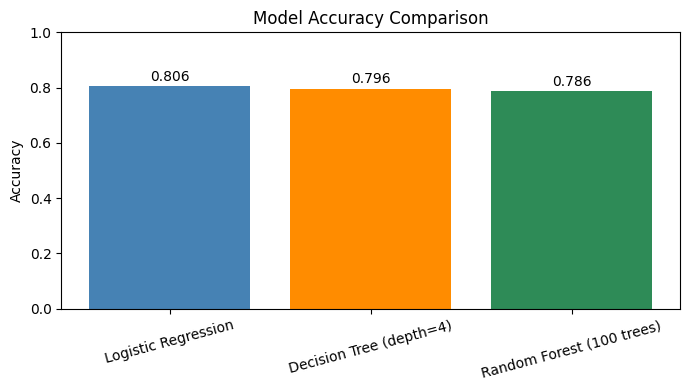

In [23]:
plt.figure(figsize=(7, 4))
plt.bar(comparison['Model'], comparison['Accuracy'], color=['steelblue', 'darkorange', 'seagreen'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
for i, v in enumerate(comparison['Accuracy']):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()


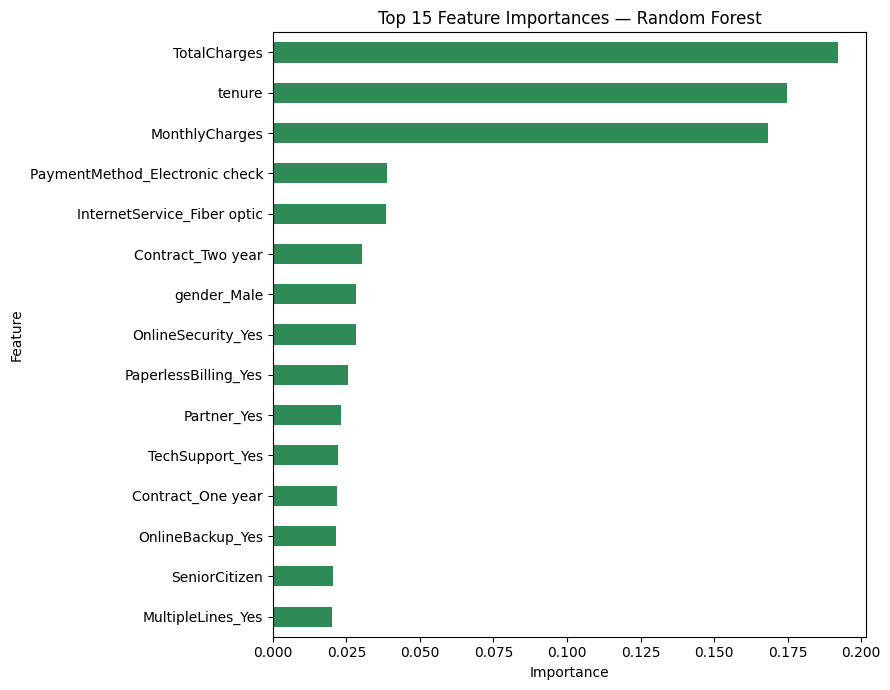

TotalCharges                      0.192096
tenure                            0.174733
MonthlyCharges                    0.168413
PaymentMethod_Electronic check    0.038771
InternetService_Fiber optic       0.038641
Contract_Two year                 0.030176
gender_Male                       0.028321
OnlineSecurity_Yes                0.028191
PaperlessBilling_Yes              0.025617
Partner_Yes                       0.023326
TechSupport_Yes                   0.022209
Contract_One year                 0.021710
OnlineBackup_Yes                  0.021431
SeniorCitizen                     0.020484
MultipleLines_Yes                 0.019969
dtype: float64

In [24]:
# Feature importances for Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
importances.sort_values().plot(kind='barh', color='seagreen')
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importances


### Model Interpretation

Based on the Random Forest feature importances, `TotalCharges`, `tenure`, and `MonthlyCharges`
are by far the three most predictive features, together accounting for more importance than every other
feature combined. Contract-related features (`Contract_Two year`, `Contract_One year`) and service
features like `OnlineSecurity_Yes` and `TechSupport_Yes` also appear in the top group, but with
noticeably smaller importance scores. This aligns well with the statistical findings in Part 2: the
chi-square test showed contract type is significantly associated with churn, and the t-test showed
monthly charges differ significantly between churned and retained customers. The models essentially
confirm the same story the statistics told — new, high-paying customers without long-term contracts or
add-on services (security/tech support) are the highest churn risk — while also revealing that the raw
billing/tenure numbers carry even more predictive weight than contract type alone.

### Final Recommendation

Interestingly, the simplest model — Logistic Regression — achieved the best accuracy of the three
(80.6%), slightly ahead of the Decision Tree (79.6%) and Random Forest (78.6%), which suggests the
churn signal here is largely linear/additive rather than driven by complex feature interactions. Taking
the combined statistical and model evidence together, the company should concentrate retention efforts
on customers who are both new (low tenure) and paying high monthly charges, and proactively offer them
a discounted incentive to move off month-to-month billing onto a one- or two-year contract, while also
bundling in security/tech-support add-ons — both were significant churn-reducing factors — within the
first few months of the relationship, since that is the window where churn risk is highest.

## Part 4: Professional Communication & GitHub Portfolio

This section documents the professional publishing steps for this project. A ready-to-use
`README.md` has been prepared alongside this notebook and the `churn_queries.sql` file — see the
accompanying files for the exact content to push to GitHub.

**Suggested repository structure:**
```
customer-churn-analysis/
├── Customer_Churn_Analysis.ipynb
├── churn_queries.sql
├── README.md
└── data/
    └── Telco-Customer-Churn.csv   (optional)
```

**To publish:**
1. Create a new public GitHub repository named `customer-churn-analysis`.
2. Add the notebook, `churn_queries.sql`, and `README.md` (all provided as separate downloadable
   files alongside this notebook).
3. Commit and push to the `main` branch.
4. (Optional) Record a short 2-minute screen walkthrough of the notebook and link it in the README.
5. Share the public repository URL as the assignment deliverable.
